#**PART C: PREDICTIVE MODELLING**

---

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.2 MB/s eta 0:00:00


Necessary Imports

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Model
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rank_gauss = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pyarrow as pa
import pyarrow.parquet as pq

import warnings
warnings.filterwarnings('ignore')

Mounting over the google drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/veritas_cassandra/'


Mounted at /content/drive


Importing the transformed datasets from PART B of the ps through parquet files from drive.

In [7]:
print("Loading Master Feature Sets for Ensemble Training...")
train_master = pd.read_parquet(f'{drive_path}train_final_master.parquet')
test_master = pd.read_parquet(f'{drive_path}test_final_master.parquet')

train_ids = train_master['id'].values
test_ids = test_master['id'].values
y = train_master['target'].values

X = train_master.drop(columns=['id', 'target'])
X_test = test_master.drop(columns=['id'])
print(f"Total Training Samples: {X.shape[0]}")
print(f"Total Test Samples:     {X_test.shape[0]}")
print(f"Total Feature Count:    {X.shape[1]}")
print(f"Total Feature Count:    {X_test.shape[1]}")

Loading Master Feature Sets for Ensemble Training...
Total Training Samples: 148462
Total Test Samples:     178564
Total Feature Count:    358
Total Feature Count:    358


In [8]:
dae_features = [c for c in X.columns if 'dae' in c.lower() or 'embed' in c.lower()]

interaction_features = [c for c in X.columns if c.startswith('inter_')]

other_features = [c for c in X.columns if c not in dae_features + interaction_features]

print(f"DAE Embedding Features: {len(dae_features)}")
print(f"Interaction Features:   {len(interaction_features)}")
print(f"Other Features:         {len(other_features)}")

DAE Embedding Features: 128
Interaction Features:   20
Other Features:         210


##**Strategic Feature Pruning**
###***LightGBM Based Recursive Feature Elimination***



####Recursive Feature Elimination (RFE) via Gradient Boosted Decision Trees

This removes noisy/redundant features, improving model generalization, speed, and reducing overfitting.
Using LightGBM’s gain importance ensures, that only those features that actually contribute most to prediction, not just correlation are retained.

In [9]:
import lightgbm as lgb
print("Auditing 358 Features for Predictive Gain")
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'learning_rate': 0.05,
    'num_leaves': 31,
}

dtrain = lgb.Dataset(X, label=y)
clf = lgb.train(lgb_params, dtrain, num_boost_round=500)
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)
NUM_TO_KEEP = 250
selected_features = fi.head(NUM_TO_KEEP)['feature'].tolist()

X_selected = X[selected_features]
X_test_selected = X_test[selected_features]

print(f"Audit Complete. Dropped {X.shape[1] - len(selected_features)} redundant features.")

Auditing 358 Features for Predictive Gain
Audit Complete. Dropped 108 redundant features.


Parsimony: By dropping 100+ features, selecting only the "Elite" features.

In [11]:
print(f"Total Feature Count:    {X_selected.shape[1]}")
print(f"Total Feature Count:    {X_test_selected.shape[1]}")

Total Feature Count:    250
Total Feature Count:    250


In [12]:
dae_features = [c for c in X_selected.columns if 'dae' in c.lower() or 'embed' in c.lower()]

interaction_features = [c for c in X_selected.columns if c.startswith('inter_')]

other_features = [c for c in X_selected.columns if c not in dae_features + interaction_features]

print(f"DAE Embedding Features: {len(dae_features)}")
print(f"Interaction Features:   {len(interaction_features)}")
print(f"Other Features:         {len(other_features)}")

DAE Embedding Features: 128
Interaction Features:   20
Other Features:         102


The **advanced representations (DAE) and interactions** **discovered in PHASE-2** are not just secondary—they are dominant signals that rank in the top percentiles of importance.

####Information Gain Filtering & Phase 2 Signal Validation

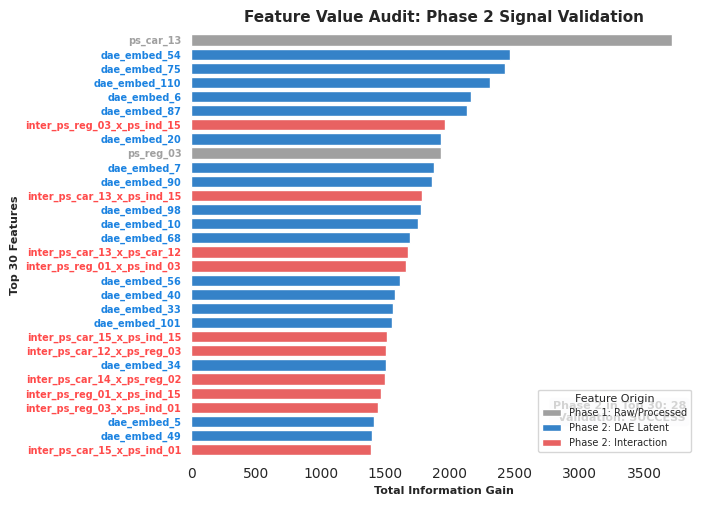

REPORT INSIGHT: 28 out of the top 30 features (93.3%) come from Phase 2.


In [20]:
plt.figure(figsize=(7, 5))
sns.set_style("white")
ax = sns.barplot(
    x="importance",
    y="feature",
    hue="Category",
    data=top_30,
    palette=palette_map,
    dodge=False
)

for i, (label, category) in enumerate(zip(top_30['feature'], top_30['Category'])):
    ax.get_yticklabels()[i].set_color(palette_map[category])
    ax.get_yticklabels()[i].set_weight('bold')
    ax.get_yticklabels()[i].set_fontsize(7)

plt.title("Feature Value Audit: Phase 2 Signal Validation", fontsize=11, fontweight='bold', pad=8)
plt.xlabel("Total Information Gain", fontsize=8, fontweight='bold')
plt.ylabel("Top 30 Features", fontsize=8, fontweight='bold')

plt.legend(title="Feature Origin", title_fontsize=8, fontsize=7, loc='lower right', frameon=True)

phase_2_count = top_30[top_30['Category'].str.contains('Phase 2')].shape[0]

text_box = f"Phase 2 in Top 30: {phase_2_count}\nValidation: SUCCESS"

plt.text(0.98, 0.08, text_box, transform=ax.transAxes,
         fontsize=8, fontweight='bold', ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0F2F6', alpha=0.8, edgecolor='none'))

sns.despine(left=True, bottom=True)
plt.tight_layout(pad=0.5)
plt.show()

print(f"REPORT INSIGHT: {phase_2_count} out of the top 30 features ({phase_2_count/30*100:.1f}%) come from Phase 2.")

To maximize the predictive signal for the Veritas Cassandra, a high-dimensional feature set was engineered comprising Denoising Autoencoder (DAE) latent embeddings, targeted interaction terms, and optimized raw/processed variables. This feature space is modeled through a **multi-modal Stacked Ensemble—integrating XGBoost, LightGBM, CatBoost, and a Deep Neural Network—using a 10-Fold Out-of-Fold (OOF) framework and a Logistic Meta-Learner** to ensure maximum generalization and architectural diversity.

##**Model Optimization: Adaptive Hyperparameter Search (Optuna)**
###***Optuna for LightGBM***



This uses a 5-Fold Stratified CV inside the search. It focuses on feature_fraction to handle your 250 features efficiently.

In [29]:
def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.05),
        'num_leaves': trial.suggest_int('num_leaves', 20, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.7),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 150),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, val_idx in cv.split(X_selected, y):
        xt, xv = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
        yt, yv = y[train_idx], y[val_idx]

        dtrain = lgb.Dataset(xt, label=yt)
        dval = lgb.Dataset(xv, label=yv, reference=dtrain)

        model = lgb.train(
            params, dtrain,
            valid_sets=[dval],
            num_boost_round=2000,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        preds = model.predict(xv)
        cv_scores.append(roc_auc_score(yv, preds))

    return np.mean(cv_scores)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=15)
print(f"Best LGBM Params: {lgb_study.best_params}")

[I 2026-04-04 14:10:22,803] A new study created in memory with name: no-name-5c5f6169-44c0-40cc-bc36-9c6958c68aba


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid_0's auc: 0.609825
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[110]	valid_0's auc: 0.62968
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's auc: 0.625841
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[52]	valid_0's auc: 0.638
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[188]	valid_0's auc: 0.612375


[I 2026-04-04 14:13:31,653] Trial 0 finished with value: 0.6231440958912314 and parameters: {'learning_rate': 0.03223185645458658, 'num_leaves': 63, 'feature_fraction': 0.4655599814962998, 'bagging_fraction': 0.8284085345013752, 'bagging_freq': 5, 'min_child_samples': 53, 'lambda_l1': 0.0005613151104951721, 'lambda_l2': 0.04881713634324107}. Best is trial 0 with value: 0.6231440958912314.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[136]	valid_0's auc: 0.611801
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[299]	valid_0's auc: 0.635442
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[92]	valid_0's auc: 0.626088
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[301]	valid_0's auc: 0.641916
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[604]	valid_0's auc: 0.62036


[I 2026-04-04 14:19:14,458] Trial 1 finished with value: 0.6271214511474794 and parameters: {'learning_rate': 0.009899418715353171, 'num_leaves': 73, 'feature_fraction': 0.4026306986174241, 'bagging_fraction': 0.7727890683345102, 'bagging_freq': 6, 'min_child_samples': 28, 'lambda_l1': 2.4396407180166166, 'lambda_l2': 4.426852024002077e-06}. Best is trial 1 with value: 0.6271214511474794.


...

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[241]	valid_0's auc: 0.610549
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[124]	valid_0's auc: 0.629852
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[186]	valid_0's auc: 0.6286
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[138]	valid_0's auc: 0.646311
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[252]	valid_0's auc: 0.618082


[I 2026-04-04 15:07:15,803] Trial 13 finished with value: 0.6266787416846629 and parameters: {'learning_rate': 0.017342340910601307, 'num_leaves': 48, 'feature_fraction': 0.507419078859161, 'bagging_fraction': 0.7153308149523312, 'bagging_freq': 2, 'min_child_samples': 108, 'lambda_l1': 1.876176121964039e-06, 'lambda_l2': 2.3304603080511516e-08}. Best is trial 11 with value: 0.6290249722112261.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[600]	valid_0's auc: 0.612001
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[197]	valid_0's auc: 0.632215
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[262]	valid_0's auc: 0.630357
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[165]	valid_0's auc: 0.6464
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[257]	valid_0's auc: 0.618059


[I 2026-04-04 15:12:03,560] Trial 14 finished with value: 0.627806622018945 and parameters: {'learning_rate': 0.025739635861161653, 'num_leaves': 20, 'feature_fraction': 0.44750582450323895, 'bagging_fraction': 0.8249664440033136, 'bagging_freq': 2, 'min_child_samples': 83, 'lambda_l1': 0.008820998233672321, 'lambda_l2': 0.9589272866887164}. Best is trial 11 with value: 0.6290249722112261.


Best LGBM Params: {'learning_rate': 0.0164123789714758, 'num_leaves': 21, 'feature_fraction': 0.4915786937140095, 'bagging_fraction': 0.8923855406650433, 'bagging_freq': 1, 'min_child_samples': 103, 'lambda_l1': 4.415223789016992e-06, 'lambda_l2': 4.319909985727286}


###***Optuna for XGBoost***

XGBoost is excellent at finding the non-linear interactions in your Phase 2 features.

In [9]:
!pip install xgboost

In [36]:
import xgboost as xgb

def xgb_objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 42,
        'tree_method': 'hist',
        'device': 'cuda',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.7),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 1e-3, 2.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-2, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-2, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'n_jobs': 2
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X_selected, y):
        xt, xv = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
        yt, yv = y[train_idx], y[val_idx]

        dtrain = xgb.DMatrix(xt, label=yt)
        dval = xgb.DMatrix(xv, label=yv)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, 'eval')],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = model.predict(dval)
        cv_scores.append(roc_auc_score(yv, preds))

    return np.mean(cv_scores)


xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=15)

print(f"Best XGB Params: {xgb_study.best_params}")

[I 2026-04-04 15:21:27,540] A new study created in memory with name: no-name-0659bd43-5714-41a6-9b64-9124fdfd3609
[I 2026-04-04 15:25:01,638] Trial 0 finished with value: 0.6267100658017576 and parameters: {'learning_rate': 0.012996677570799916, 'max_depth': 4, 'colsample_bytree': 0.6782631783413207, 'subsample': 0.847407686834861, 'gamma': 0.002035004354201665, 'alpha': 0.337590934605374, 'lambda': 5.876836743255873, 'min_child_weight': 2}. Best is trial 0 with value: 0.6267100658017576.
[I 2026-04-04 15:28:51,740] Trial 1 finished with value: 0.6272782081716856 and parameters: {'learning_rate': 0.010284086260189626, 'max_depth': 4, 'colsample_bytree': 0.4156763320505714, 'subsample': 0.8982351285868307, 'gamma': 0.03852905619770808, 'alpha': 0.024332095160333325, 'lambda': 0.022971761705845913, 'min_child_weight': 3}. Best is trial 1 with value: 0.6272782081716856.
[I 2026-04-04 15:31:03,285] Trial 2 finished with value: 0.6243513878249961 and parameters: {'learning_rate': 0.02211466

Best XGB Params: {'learning_rate': 0.020134157063418666, 'max_depth': 3, 'colsample_bytree': 0.4025319028825559, 'subsample': 0.8922012939545183, 'gamma': 0.07566914025659227, 'alpha': 0.21704176672787992, 'lambda': 0.7642031289189386, 'min_child_weight': 5}


Scaling the selected features for NN input and setting up the OOF prediction containers with 5-fold stratified cross-validation.

In [13]:
from sklearn.preprocessing import StandardScaler

# 1. Scaling for the Neural Network
scaler = StandardScaler()
X_nn_scaled = scaler.fit_transform(X_selected)
X_test_nn_scaled = scaler.transform(X_test_selected)

# 2. OOF Containers
train_oof = pd.DataFrame(index=X_selected.index)
test_preds = pd.DataFrame(index=X_test_selected.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
print(X_nn_scaled.shape)       # should be (n_rows, 250)
print(X_test_nn_scaled.shape)  # should be (m_rows, 250)

(148462, 250)
(178564, 250)


In [15]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


#***Predictive Model***

###**Stacked Ensemble of XGBoost, CatBoost, LightGBM and NN with Ridge and Logistic Regressor Meta Learners**

Using a stacked ensemble of Neural Network, CatBoost, LightGBM, and XGBoost with a Ridge regression meta-learner to optimally combine model predictions.

###**CatBoost Model**

In [16]:
from catboost import CatBoostClassifier

print("Running Model: CatBoost...")
cat_oof = np.zeros(len(X_selected))
cat_test = np.zeros(len(X_test_selected))

cat_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 6,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 0
}

for f, (tr_idx, val_idx) in enumerate(cv.split(X_selected, y)):
    model = CatBoostClassifier(**cat_params)

    # FIX: Use .iloc for X (DataFrame) and standard [ ] for y (NumPy)
    model.fit(
        X_selected.iloc[tr_idx], y[tr_idx],
        eval_set=(X_selected.iloc[val_idx], y[val_idx]),
        early_stopping_rounds=100
    )

    # Store OOF predictions
    cat_oof[val_idx] = model.predict_proba(X_selected.iloc[val_idx])[:, 1]

    # Add to Test predictions (averaging over folds)
    cat_test += model.predict_proba(X_test_selected)[:, 1] / 5

train_oof['cat'] = cat_oof
test_preds['cat'] = cat_test

# Calculate Gini
gini_score = 2 * roc_auc_score(y, cat_oof) - 1
print(f"CatBoost OOF Gini: {gini_score:.5f}")

Running Model: CatBoost...
CatBoost OOF Gini: 0.26059


**Neural Network Architecture**

In [17]:
class JahrerNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            # Block 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            # Block 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


nn_oof  = np.zeros(len(X_nn_scaled))
nn_test = np.zeros(len(X_test_nn_scaled))

X_test_tensor = torch.FloatTensor(X_test_nn_scaled).cuda()

for f, (tr_idx, val_idx) in enumerate(cv.split(X_nn_scaled, y)):
    print(f"\n── Fold {f+1}/5 ──")

    X_tr = torch.FloatTensor(X_nn_scaled[tr_idx])
    y_tr = torch.FloatTensor(y[tr_idx]).unsqueeze(1)
    X_va = torch.FloatTensor(X_nn_scaled[val_idx])
    y_va = torch.FloatTensor(y[val_idx]).unsqueeze(1)

    train_dl = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=1024, shuffle=True
    )

    model     = JahrerNet(250).cuda()
    criterion = nn.BCELoss()

    optimizer = torch.optim.SGD(
        model.parameters(), lr=0.01,
        momentum=0.9, weight_decay=1e-5
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=2, gamma=0.7
    )

    best_auc   = 0
    best_state = None

    for epoch in range(10):
        model.train()
        epoch_loss = 0
        for bx, by in train_dl:
            optimizer.zero_grad()
            out  = model(bx.cuda())
            loss = criterion(out, by.cuda())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()

        model.eval()
        with torch.no_grad():
            va_preds = model(X_va.cuda()).cpu().numpy().flatten()
            va_auc   = roc_auc_score(y[val_idx], va_preds)

        print(f"  Epoch {epoch+1:02d} | LR: {scheduler.get_last_lr()[0]:.5f} "
              f"| Loss: {epoch_loss/len(train_dl):.4f} | Val AUC: {va_auc:.5f}")


        if va_auc > best_auc:
            best_auc   = va_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        nn_oof[val_idx] = model(X_va.cuda()).cpu().numpy().flatten()
        nn_test += model(X_test_tensor).cpu().numpy().flatten() / 5

    fold_gini = 2 * roc_auc_score(y[val_idx], nn_oof[val_idx]) - 1
    print(f"Fold {f+1} Best Gini: {fold_gini:.5f}")

train_oof['nn'] = nn_oof
test_preds['nn'] = nn_test

final_nn_gini = 2 * roc_auc_score(y, nn_oof) - 1
print(f"\n TOTAL NN OOF GINI: {final_nn_gini:.5f}")


── Fold 1/5 ──
  Epoch 01 | LR: 0.01000 | Loss: 0.1921 | Val AUC: 0.58375
  Epoch 02 | LR: 0.00700 | Loss: 0.1597 | Val AUC: 0.58790
  Epoch 03 | LR: 0.00700 | Loss: 0.1595 | Val AUC: 0.58947
  Epoch 04 | LR: 0.00490 | Loss: 0.1587 | Val AUC: 0.59079
  Epoch 05 | LR: 0.00490 | Loss: 0.1580 | Val AUC: 0.59168
  Epoch 06 | LR: 0.00343 | Loss: 0.1575 | Val AUC: 0.59340
  Epoch 07 | LR: 0.00343 | Loss: 0.1571 | Val AUC: 0.59335
  Epoch 08 | LR: 0.00240 | Loss: 0.1568 | Val AUC: 0.59369
  Epoch 09 | LR: 0.00240 | Loss: 0.1568 | Val AUC: 0.59409
  Epoch 10 | LR: 0.00168 | Loss: 0.1572 | Val AUC: 0.59436
Fold 1 Best Gini: 0.18873

── Fold 2/5 ──
  Epoch 01 | LR: 0.01000 | Loss: 0.1902 | Val AUC: 0.59127
  Epoch 02 | LR: 0.00700 | Loss: 0.1607 | Val AUC: 0.59921
  Epoch 03 | LR: 0.00700 | Loss: 0.1594 | Val AUC: 0.60184
  Epoch 04 | LR: 0.00490 | Loss: 0.1593 | Val AUC: 0.60371
  Epoch 05 | LR: 0.00490 | Loss: 0.1583 | Val AUC: 0.60534
  Epoch 06 | LR: 0.00343 | Loss: 0.1583 | Val AUC: 0.6069

**LightGBM Model**

In [18]:
import lightgbm as lgb

# Best Params from your Optuna run
LGB_BEST = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.0164123789714758,
    'num_leaves': 21,
    'feature_fraction': 0.4915786937140095,
    'bagging_fraction': 0.8923855406650433,
    'bagging_freq': 1,
    'min_child_samples': 103,
    'lambda_l1': 4.415223789016992e-06,
    'lambda_l2': 4.319909985727286
}

print("Running Tuned LightGBM OOF...")
lgb_oof = np.zeros(len(X_selected))
lgb_test = np.zeros(len(X_test_selected))

for f, (tr_idx, val_idx) in enumerate(cv.split(X_selected, y)):
    xt, xv = X_selected.iloc[tr_idx], X_selected.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]

    model = lgb.LGBMClassifier(**LGB_BEST, n_estimators=5000)
    model.fit(xt, yt, eval_set=[(xv, yv)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])

    lgb_oof[val_idx] = model.predict_proba(xv)[:, 1]
    lgb_test += model.predict_proba(X_test_selected)[:, 1] / 5

train_oof['lgb'] = lgb_oof
test_preds['lgb'] = lgb_test
print(f"LGBM OOF Gini: {2 * roc_auc_score(y, lgb_oof) - 1:.5f}")

Running Tuned LightGBM OOF...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[558]	valid_0's auc: 0.612479
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[366]	valid_0's auc: 0.633646
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[341]	valid_0's auc: 0.632686
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[369]	valid_0's auc: 0.64764
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[421]	valid_0's auc: 0.618674
LGBM OOF Gini: 0.25706


In [27]:
!pip install xgboost==1.7.6

**XGBoost Model**

In [19]:
import xgboost as xgb

print("Running Tuned XGBoost OOF")
xgb_oof = np.zeros(len(X_selected))
xgb_test = np.zeros(len(X_test_selected))

XGB_BEST = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'tree_method': 'hist',
    'device': 'cuda',
    'learning_rate': 0.020134157063418666,
    'max_depth': 3,
    'colsample_bytree': 0.4025319028825559,
    'subsample': 0.8922012939545183,
    'gamma': 0.07566914025659227,
    'alpha': 0.21704176672787992,
    'lambda': 0.7642031289189386,
    'min_child_weight': 5,
    'n_estimators': 5000,
    'early_stopping_rounds': 100
}

for f, (tr_idx, val_idx) in enumerate(cv.split(X_selected, y)):
    xt, xv = X_selected.iloc[tr_idx], X_selected.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]

    model = xgb.XGBClassifier(**XGB_BEST)

    model.fit(
        xt, yt,
        eval_set=[(xv, yv)],
        verbose=False
    )

    xgb_oof[val_idx] = model.predict_proba(xv)[:, 1]
    xgb_test += model.predict_proba(X_test_selected)[:, 1] / 5
    print(f"Fold {f+1} Complete (Best Iteration: {model.best_iteration})")

train_oof['xgb'] = xgb_oof
test_preds['xgb'] = xgb_test
print(f"\nXGB OOF Gini: {2 * roc_auc_score(y, xgb_oof) - 1:.5f}")

Running Tuned XGBoost OOF
Fold 1 Complete (Best Iteration: 694)
Fold 2 Complete (Best Iteration: 409)
Fold 3 Complete (Best Iteration: 460)
Fold 4 Complete (Best Iteration: 460)
Fold 5 Complete (Best Iteration: 426)

XGB OOF Gini: 0.25812


**Ridge Regressor Meta-Learner**

In [20]:
from sklearn.linear_model import Ridge

# The "Trust Learner"
stacker = Ridge(alpha=1.0, fit_intercept=False)
stacker.fit(train_oof, y)

# Final Scoring
final_preds = stacker.predict(test_preds)
final_gini = 2 * roc_auc_score(y, stacker.predict(train_oof)) - 1

print(f"\n FINAL STACKED GINI: {final_gini:.5f}")

# Final Submission File
submission = pd.DataFrame({'id': test_ids, 'target': final_preds})
submission.to_csv('Cassandra_Veritas_FINAL_Stack.csv', index=False)
print("File saved! Ready for upload.")


 FINAL STACKED GINI: 0.26331
File saved! Ready for upload.


In [21]:
import os
from sklearn.linear_model import Ridge
from google.colab import drive

drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/veritas_cassandra/'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

stacker = Ridge(alpha=1.0, fit_intercept=False)
stacker.fit(train_oof, y)

final_preds = stacker.predict(test_preds)

stacker_train_preds = stacker.predict(train_oof)
final_gini = 2 * roc_auc_score(y, stacker_train_preds) - 1

print(f"\n FINAL STACKED GINI: {final_gini:.5f}")

submission = pd.DataFrame({
    'id': test_ids,
    'target': final_preds
})

local_filename = 'Cassandra_Veritas_FINAL_Stack01.csv'
drive_full_path = os.path.join(drive_path, local_filename)

submission.to_csv(drive_full_path, index=False)
submission.to_csv(local_filename, index=False)

print(f"Success! Submission uploaded to: {drive_full_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 FINAL STACKED GINI: 0.26331
Success! Submission uploaded to: /content/drive/MyDrive/veritas_cassandra/Cassandra_Veritas_FINAL_Stack01.csv


**Logistic Regressor Meta-Learner**

In [22]:
from sklearn.linear_model import LogisticRegression
import os

log_stacker = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)

log_stacker.fit(train_oof, y)

log_final_preds = log_stacker.predict_proba(test_preds)[:, 1]

log_train_preds = log_stacker.predict_proba(train_oof)[:, 1]
log_final_gini = 2 * roc_auc_score(y, log_train_preds) - 1

print(f"\n LOGISTIC STACKED GINI: {log_final_gini:.5f}")

log_submission = pd.DataFrame({
    'id': test_ids,
    'target': log_final_preds
})

log_local_filename = 'Cassandra_Logistic_Stack_Safe.csv'
log_drive_full_path = os.path.join(drive_path, log_local_filename)

log_submission.to_csv(log_drive_full_path, index=False)
log_submission.to_csv(log_local_filename, index=False)

print(f"Success! Logistic Stack saved to: {log_drive_full_path}")


 LOGISTIC STACKED GINI: 0.24472
Success! Logistic Stack saved to: /content/drive/MyDrive/veritas_cassandra/Cassandra_Logistic_Stack_Safe.csv


**Correlation Heatmap: Model Diversity**

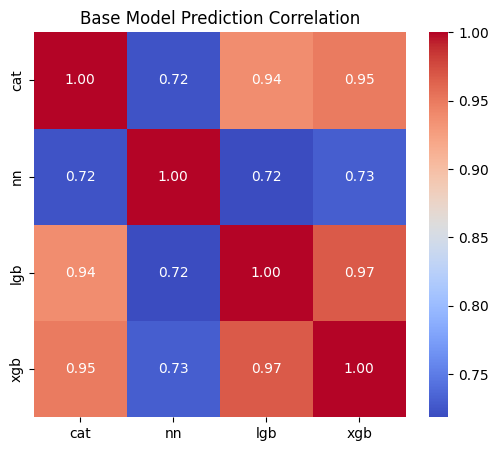

In [29]:
plt.figure(figsize=(6,5))
sns.heatmap(train_oof.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Base Model Prediction Correlation")
plt.show()

**Gini Comparison Bar Plot**

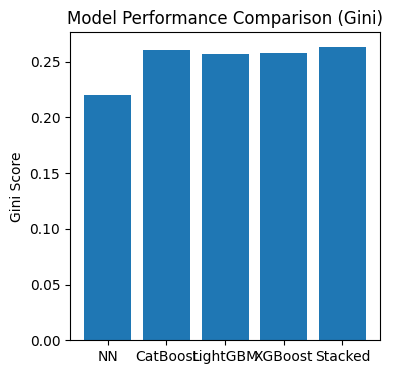

In [32]:
gini_scores = {
    'NN': 2 * roc_auc_score(y, train_oof['nn']) - 1,
    'CatBoost': 2 * roc_auc_score(y, train_oof['cat']) - 1,
    'LightGBM': 2 * roc_auc_score(y, train_oof['lgb']) - 1,
    'XGBoost': 2 * roc_auc_score(y, train_oof['xgb']) - 1,
    'Stacked': 2 * roc_auc_score(y, stacker.predict(train_oof)) - 1
}

plt.figure(figsize=(4,4))
plt.bar(gini_scores.keys(), gini_scores.values())
plt.title("Model Performance Comparison (Gini)")
plt.ylabel("Gini Score")
plt.show()

**ROC CURVE:Stack vs Base Model**


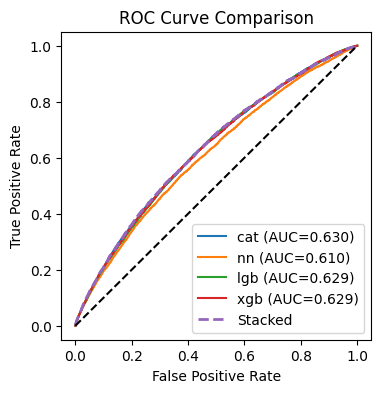

In [33]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(4,4))

for col in train_oof.columns:
    fpr, tpr, _ = roc_curve(y, train_oof[col])
    plt.plot(fpr, tpr, label=f"{col} (AUC={auc(fpr,tpr):.3f})")

# Final stack
stack_preds = stacker.predict(train_oof)
fpr, tpr, _ = roc_curve(y, stack_preds)
plt.plot(fpr, tpr, linestyle='--', linewidth=2, label="Stacked")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [24]:

print("CHECKING OOF DATA (TRAIN)")
try:
    print(f"Rows: {train_oof.shape[0]} | Models: {train_oof.columns.tolist()}")
    print(f"Sample Data:\n{train_oof.head(2)}")
    if train_oof.isnull().values.any():
        print("!!! WARNING: train_oof has NaN values!")
except NameError:
    print("!!! CRITICAL: 'train_oof' is GONE. Runtime reset wiped it.")
except Exception as e:
    print(f"Error: {e}")

print("\n--- [2] CHECKING TEST DATA (FINAL SUBMISSION) ---")
try:
    print(f"Submission Rows: {submission.shape[0]}")
    print(f"Target Range: {submission['target'].min():.4f} to {submission['target'].max():.4f}")
    print(f"Mean Prediction: {submission['target'].mean():.4f}")

    if 'id' not in submission.columns:
        print("!!! CRITICAL: 'id' column is MISSING from submission.")
except NameError:
    print("!!! CRITICAL: 'submission' dataframe not found.")
except Exception as e:
    print(f"Error: {e}")

CHECKING OOF DATA (TRAIN)
Rows: 148462 | Models: ['cat', 'nn', 'lgb', 'xgb']
Sample Data:
        cat        nn       lgb       xgb
0  0.032433  0.074338  0.034378  0.035921
1  0.026564  0.027771  0.026941  0.025418

--- [2] CHECKING TEST DATA (FINAL SUBMISSION) ---
Submission Rows: 178564
Target Range: 0.0116 to 0.3670
Mean Prediction: 0.0369


In [27]:

print("--- [STEP 1] CHECKING INPUT TABLES ---")
for df_name, df in [("Train OOF", train_oof), ("Test Preds", test_preds)]:
    print(f"\nChecking {df_name}:")
    print(f" - Columns: {df.columns.tolist()}")
    print(f" - Any NaNs? {df.isna().values.any()}")
    print(f" - Row Count: {len(df)}")
    print(f" - Model Means:\n{df.mean()}")

print("\n--- [STEP 2] CHECKING THE FINAL STACK ---")
print(f"Final Gini: {final_gini:.5f}")
print(f"Target Min: {submission['target'].min():.6f}")
print(f"Target Max: {submission['target'].max():.6f}")
print(f"Target Mean: {submission['target'].mean():.6f}")

if submission['target'].isna().any():
    print("!!! WARNING: YOUR FINAL CSV HAS NaN VALUES !!!")
else:
    print("DATA IS CLEAN: No NaNs found.")

--- [STEP 1] CHECKING INPUT TABLES ---

Checking Train OOF:
 - Columns: ['cat', 'nn', 'lgb', 'xgb']
 - Any NaNs? False
 - Row Count: 148462
 - Model Means:
cat    0.036392
nn     0.076739
lgb    0.036406
xgb    0.036641
dtype: float64

Checking Test Preds:
 - Columns: ['cat', 'nn', 'lgb', 'xgb']
 - Any NaNs? False
 - Row Count: 178564
 - Model Means:
cat    0.036326
nn     0.076489
lgb    0.036342
xgb    0.036572
dtype: float64

--- [STEP 2] CHECKING THE FINAL STACK ---
Final Gini: 0.26331
Target Min: 0.011614
Target Max: 0.367026
Target Mean: 0.036943
DATA IS CLEAN: No NaNs found.
